# Introducing Colab

Learn about Google Colab and set up a Google account (if you don't already have one) [here](https://colab.research.google.com/)

You should be able to use the free tier or minimal spend to complete all the projects in the class. I personally signed up for Colab Pro+ and I'm loving it - but it's not required.

To see some of what Colab can do, please follow the link below!

https://colab.research.google.com/drive/1DjcrYDZldAXKJ08x1uYIVCtItoLPk1Wr?usp=sharing

In [18]:
from transformers import pipeline


In [19]:
# Let's check the GPU - it should be a Tesla T4

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)
  if gpu_info.find('Tesla T4') >= 0:
    print("Success - Connected to a T4")
  else:
    print("NOT CONNECTED TO A T4")

Sun Feb  1 16:51:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 Ti     Off |   00000000:01:00.0  On |                  N/A |
|  0%   44C    P8             29W /  300W |   15602MiB /  16303MiB |      6%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# update requirements.txt
# RUN the install of missing modules

source /home/wras/llm_engineering/.venv/bin/activate
python -m ensurepip --upgrade
python -m pip install --upgrade pip setuptools wheel
pip install -r /home/wras/llm_engineering/requirements.txt

# restart jupyter kernel

In [1]:
# imports

import os
from dotenv import load_dotenv

In [2]:
from huggingface_hub import login


load_dotenv(override=True)
hf_token = os.getenv('HF_TOKEN')
login(hf_token, add_to_git_credential=False)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

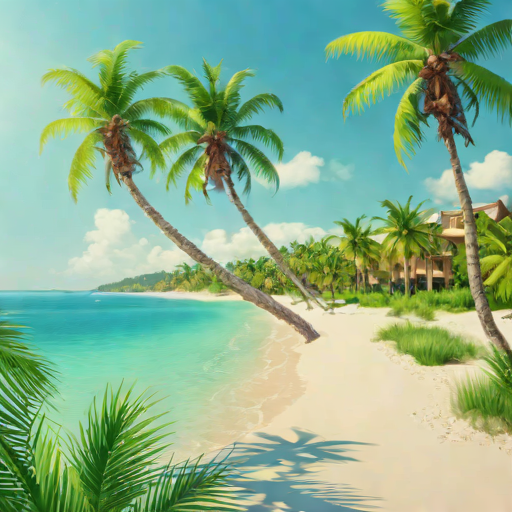

In [146]:
import diffusers
from IPython.display import display
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda")
# prompt = "A class of students learning AI engineering in a vibrant pop-art style"
prompt = "Idyllic beach , crystal clear water, bright sunny day, palm trees swaying in the breeze,  highly detailed, ultra realistic, add text: with text: Pozdrowienia z Cypru"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)


In [ ]:
# Restart the kernel

import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

: 

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

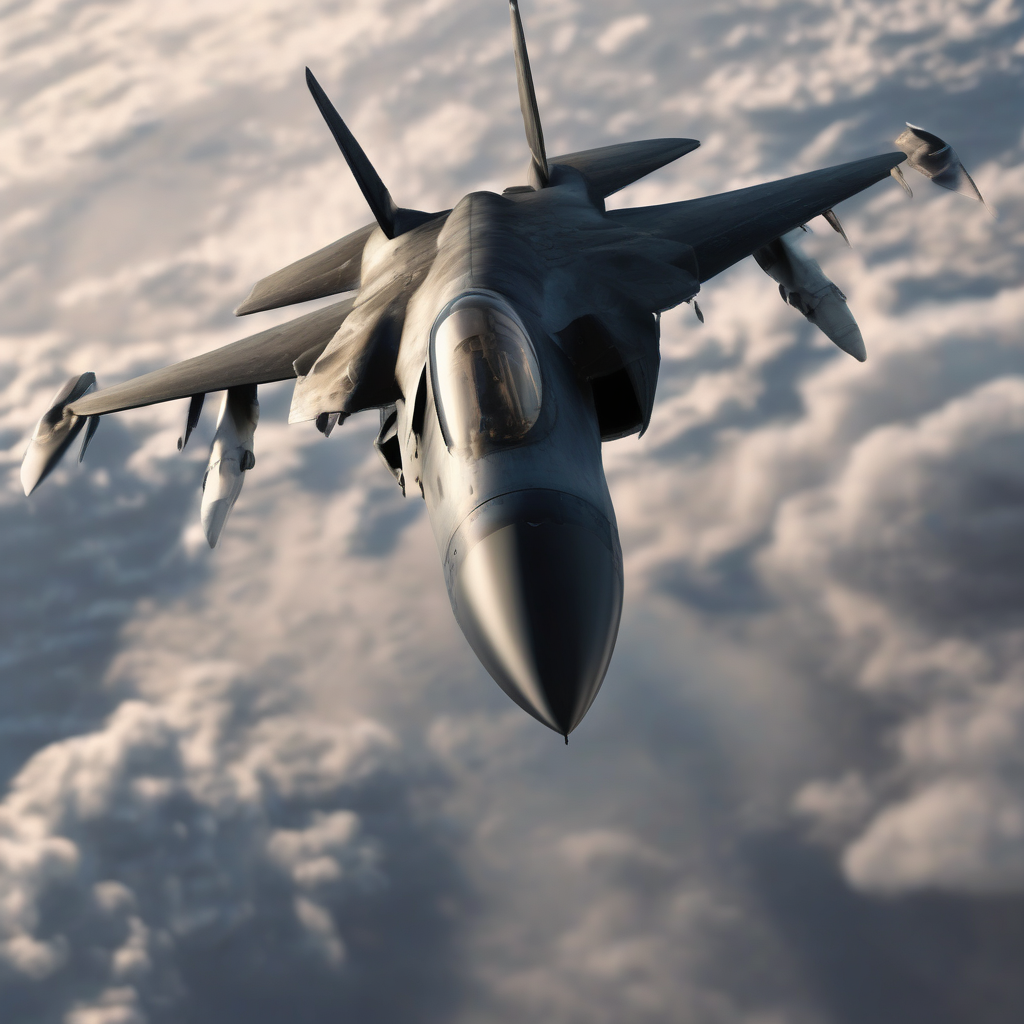

In [19]:
from IPython.display import display
from diffusers import DiffusionPipeline
import torch

pipe = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, use_safetensors=True, variant="fp16")
pipe.to("cuda")

# prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"
prompt = "ultra modern jet fighter in the sky,  highly detailed, ultra realistic, dramatic lighting, cinematic, 8k"

image = pipe(prompt=prompt, num_inference_steps=30).images[0]

display(image)


In [ ]:
# Restart the kernel

import IPython
IPython.Application.instance().kernel.do_shutdown(True)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

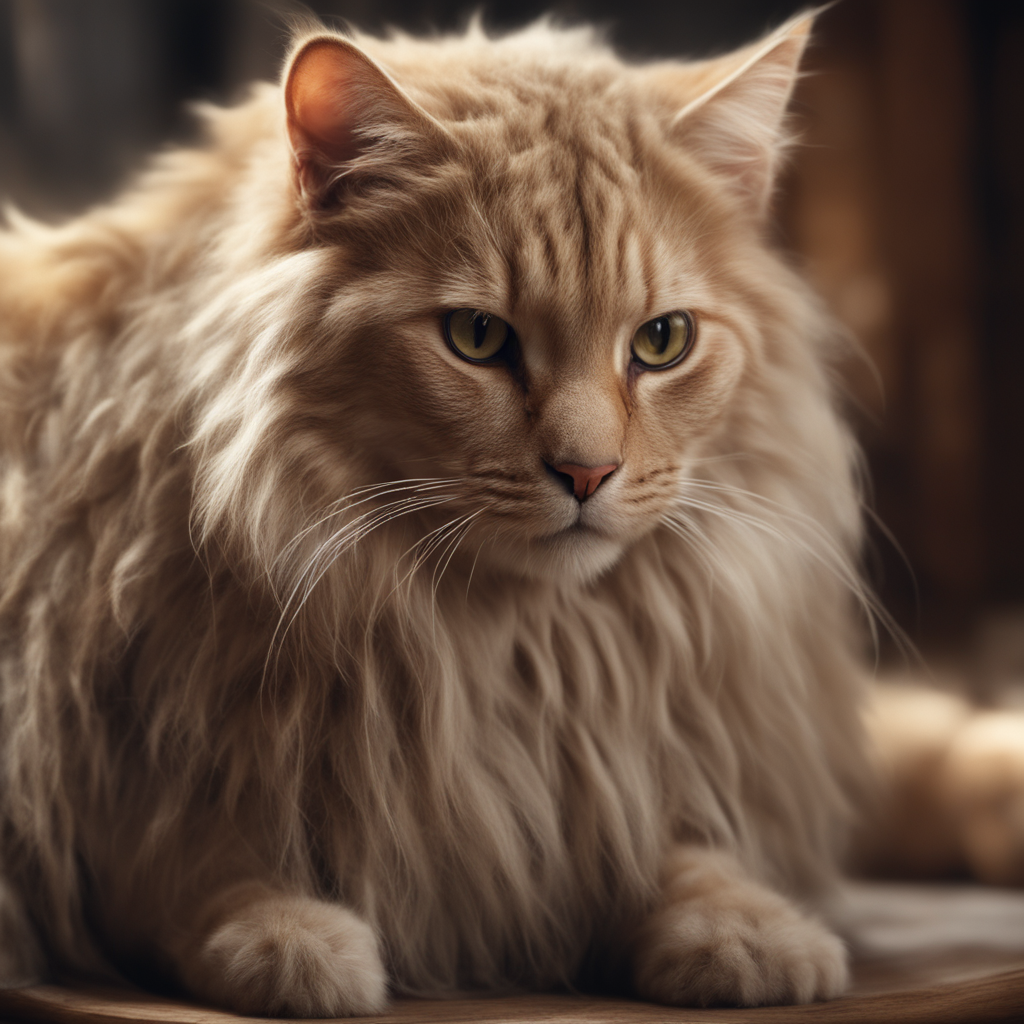

In [17]:
from diffusers import DiffusionPipeline
import torch

base = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, variant="fp16", use_safetensors=True)
base.to("cuda")
refiner = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-refiner-1.0", text_encoder_2=base.text_encoder_2, vae=base.vae, torch_dtype=torch.float16, use_safetensors=True, variant="fp16",)
refiner.to("cuda")

# Define how many steps and what % of steps to be run on each experts (80/20) here
n_steps = 40
high_noise_frac = 0.8

# prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"
prompt = "eropean home cat looking like lion, highly detailed, ultra realistic, dramatic lighting, cinematic, 8k"

# run both experts
image = base(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_end=high_noise_frac,
    output_type="latent",
).images

image = refiner(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_start=high_noise_frac,
    image=image,
).images[0]

display(image)